# The forecast regime: coherent sampling where it matters

## Scope of claims (read first)

## Methods & metrics (defined once)

In [1]:
import csv, json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "sampler_research" / "src"))
from sampler_research.phase4_eval import select_lambda_star

RUNS = PROJECT_ROOT / "outputs" / "runs"
FIG = PROJECT_ROOT / "outputs" / "figures"
PREFIX = {"6ep": "phase_4_fc48_6ep", "14ep": "phase_4_fc48_14ep"}

def show(path, width=1100):
    path = Path(path)
    if path.exists():
        display(Image(str(path), width=width))
    else:
        print(f"[missing] {path.relative_to(PROJECT_ROOT)} — run the pipeline step that writes it")

def read_csv(path):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}")
        return []
    with open(path) as fh:
        return list(csv.DictReader(fh))

def lead_dirs(label):
    out = {}
    for d in sorted(RUNS.glob(f"{PREFIX[label]}_step*")):
        try:
            out[int(d.name.split("_step")[1])] = d
        except (IndexError, ValueError):
            pass
    return out

soft = read_csv(RUNS / "phase_4_forecast_softening" / "softening_by_lead.csv")
faith = read_csv(RUNS / "phase_4_forecast_faithfulness" / "faithfulness_by_lead.csv")
print("softening rows:", len(soft), "| faithfulness rows:", len(faith))
print("6ep run dirs:", sorted(lead_dirs("6ep")), "| 14ep run dirs:", sorted(lead_dirs("14ep")))

softening rows: 112 | faithfulness rows: 112
6ep run dirs: [1, 2, 3, 4, 5, 6, 7, 8] | 14ep run dirs: [1, 2, 3, 4, 5, 6, 7, 8]


## §5.2 — Softening with lead time and training

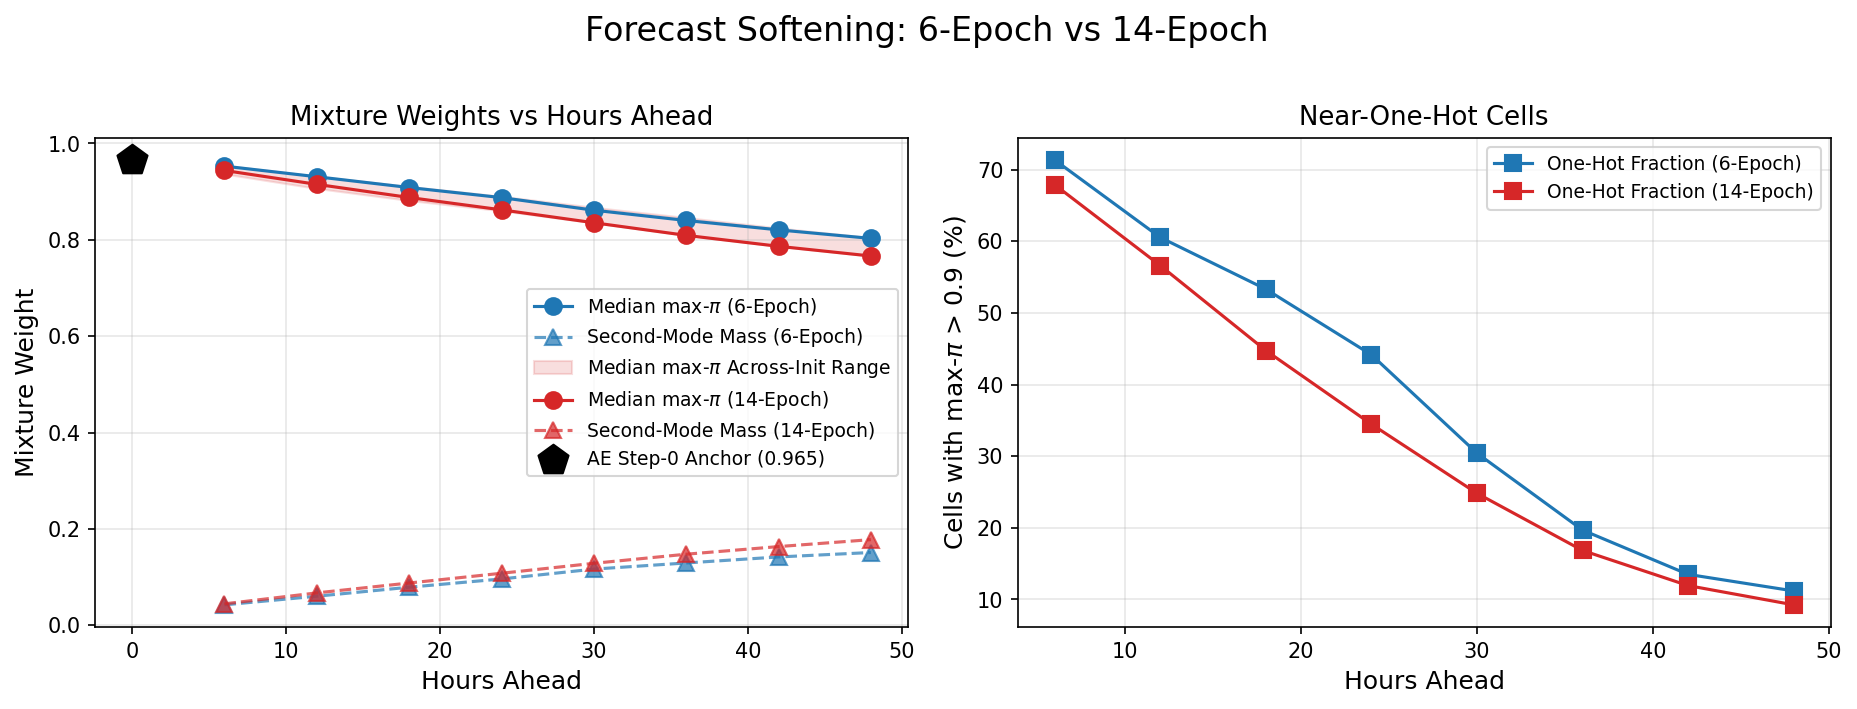

  run  lead  max-pi  one-hot    2nd   >1sig  >2sig  Keff>1.5
------------------------------------------------------------
  6ep    6h   0.953    71.3%  0.042   15.7%   2.8%     22.5%
  6ep   12h   0.931    60.5%  0.060   18.1%   1.6%     32.0%
  6ep   18h   0.908    53.3%  0.079   19.3%   1.4%     41.5%
  6ep   24h   0.887    44.1%  0.096   21.2%   1.7%     50.6%
  6ep   30h   0.861    30.4%  0.117   22.6%   2.0%     64.9%
  6ep   36h   0.840    19.7%  0.129   23.9%   2.3%     76.9%
  6ep   42h   0.821    13.5%  0.142   25.9%   2.6%     84.2%
  6ep   48h   0.803    11.2%  0.151   27.6%   2.9%     87.3%
 14ep    6h   0.944    67.9%  0.044   14.9%   2.5%     27.4%
 14ep   12h   0.915    56.6%  0.067   16.9%   1.9%     38.0%
 14ep   18h   0.888    44.7%  0.088   19.6%   2.2%     51.1%
 14ep   24h   0.862    34.5%  0.108   23.3%   3.0%     61.7%
 14ep   30h   0.835    24.8%  0.129   26.5%   4.3%     72.4%
 14ep   36h   0.809    16.8%  0.147   29.4%   4.5%     81.2%
 14ep   42h   0.786    1

In [2]:
show(FIG / "forecast_softening.png", width=1150)
def pct(x): return f"{100*float(x):.1f}%"
hdr = f"{'run':>5} {'lead':>5} {'max-pi':>7} {'one-hot':>8} {'2nd':>6} {'>1sig':>7} {'>2sig':>6} {'Keff>1.5':>9}"
print(hdr); print("-"*len(hdr))
for r in soft:
    if r["kind"] != "single":  # reference initialisation, as tabulated in the report
        continue
    print(f"{r['run']:>5} {float(r['lead_hours']):>4.0f}h {float(r['median_max_pi']):>7.3f} "
          f"{pct(r['one_hot_fraction']):>8} {float(r['median_second_mode']):>6.3f} "
          f"{pct(r['bimodal_frac_1sigma']):>7} {pct(r['bimodal_frac_2sigma']):>6} "
          f"{pct(r['keff_frac_gt_1p5']):>9}")


## §5.3 — Sampler recalibration: $\lambda^\star$ re-selection (and $\beta$)

In [3]:
for label in ("6ep", "14ep"):
    print(f"--- {label} ---")
    for step, d in sorted(lead_dirs(label).items()):
        p = d / "lambda_star.json"
        if not p.exists():
            continue
        s = json.loads(p.read_text()); reg = s.get("regime") or {}
        print(f"  +{int(reg.get('lead_hours', 6*step)):>2}h: lambda*={s['lambda_star']:>7.2f}  "
              f"matched R~={s['matched_r_tilde']:.5f}  bracketed={s['bracketed']}  "
              f"clauses={s['clauses'] or 'none'}")

d8 = lead_dirs("14ep").get(8)
if d8 and (d8 / "method1_sweep.npz").exists():
    sweep = dict(np.load(d8 / "method1_sweep.npz")); star = json.loads((d8 / "lambda_star.json").read_text())
    sel = select_lambda_star(sweep["lambdas"], sweep["r_tilde"], sweep["variance_collapsed"],
                             star["target_r_tilde"], valid=sweep["warm_start_sane"])
    assert np.isclose(sel.lambda_star, star["lambda_star"]), "lambda_star.json mismatch"
    print(f"\nreplay OK (+48h, 14ep): lambda* = {sel.lambda_star:.2f}, clauses = {sel.clauses or 'none'}")
    reg = star.get("regime") or {}; nstd = reg.get("norm_std_channel")
    if nstd and (d8 / "method1_sensitivity.npz").exists() and (d8 / "anchors.npz").exists():
        fstar = np.load(d8 / "method1_sensitivity.npz")["field_star"]
        mmap = np.load(d8 / "anchors.npz")["mode_map"]
        drift = float(np.sqrt(np.mean((fstar - mmap) ** 2)))
        print(f"physical units: Joint MAP @ lambda* RMS drift from Per-cell MAP = {drift:.3f} sigma-units "
              f"= {drift * nstd:.2f} K  (norm_std_2t = {nstd:.2f} K)")

--- 6ep ---
  + 6h: lambda*=  75.82  matched R~=0.00314  bracketed=True  clauses=none
  +12h: lambda*=  61.29  matched R~=0.00311  bracketed=True  clauses=none
  +18h: lambda*=  56.33  matched R~=0.00311  bracketed=True  clauses=none
  +24h: lambda*=  56.15  matched R~=0.00314  bracketed=True  clauses=none
  +30h: lambda*=  51.38  matched R~=0.00317  bracketed=True  clauses=none
  +36h: lambda*=  47.00  matched R~=0.00315  bracketed=True  clauses=none
  +42h: lambda*=  48.13  matched R~=0.00313  bracketed=True  clauses=none
  +48h: lambda*=  52.01  matched R~=0.00311  bracketed=True  clauses=none
--- 14ep ---
  + 6h: lambda*= 116.28  matched R~=0.00328  bracketed=True  clauses=none
  +12h: lambda*=  91.54  matched R~=0.00315  bracketed=True  clauses=none
  +18h: lambda*=  97.63  matched R~=0.00311  bracketed=True  clauses=none
  +24h: lambda*=  97.02  matched R~=0.00316  bracketed=True  clauses=none
  +30h: lambda*=  88.06  matched R~=0.00332  bracketed=True  clauses=none
  +36h: lambd

## §5.4 — Joint sampling results

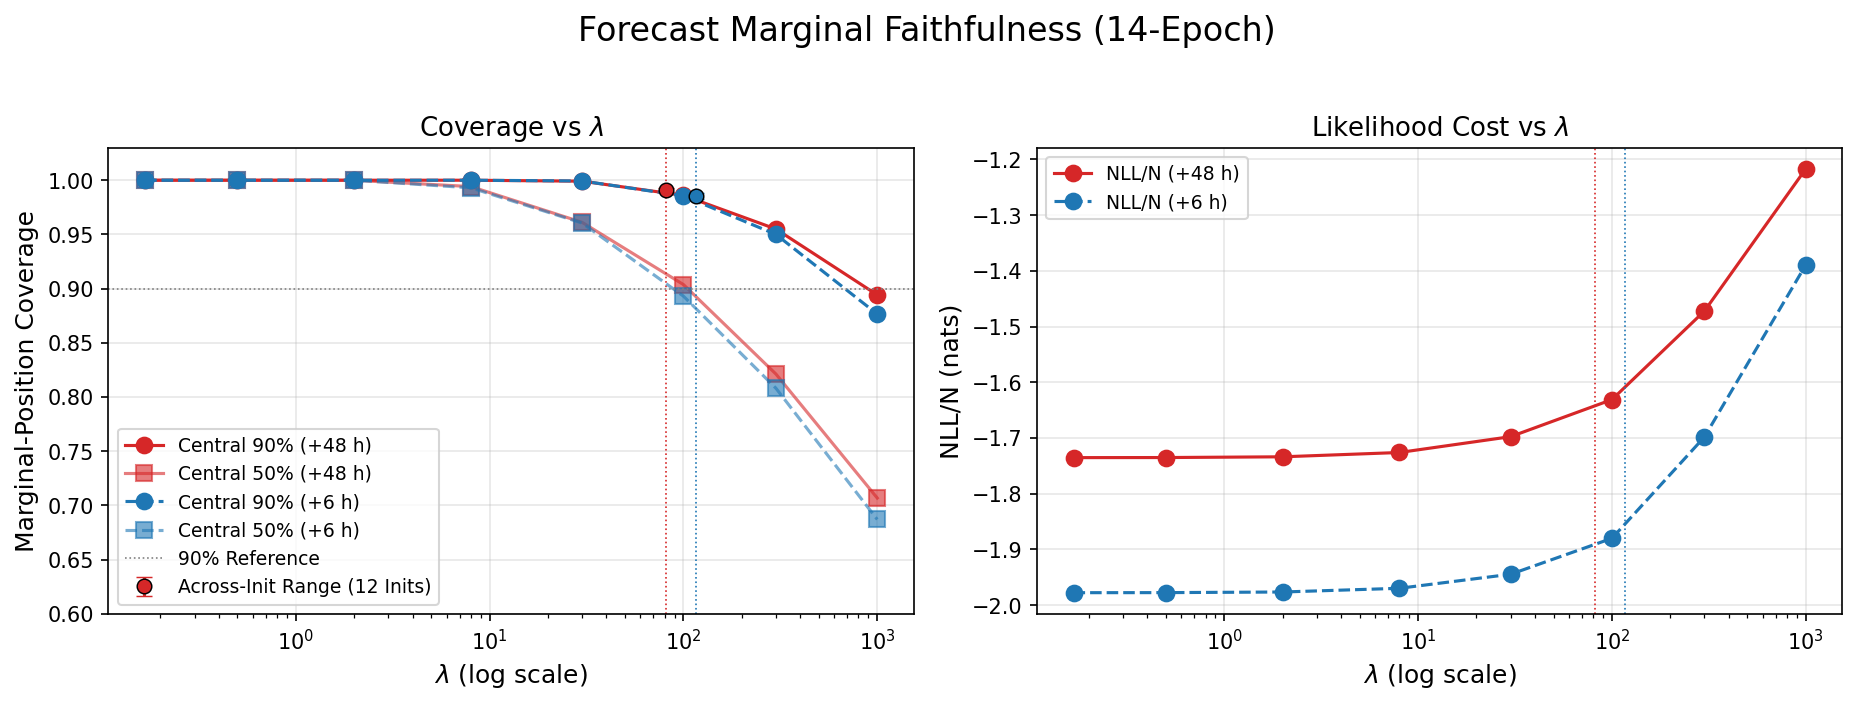

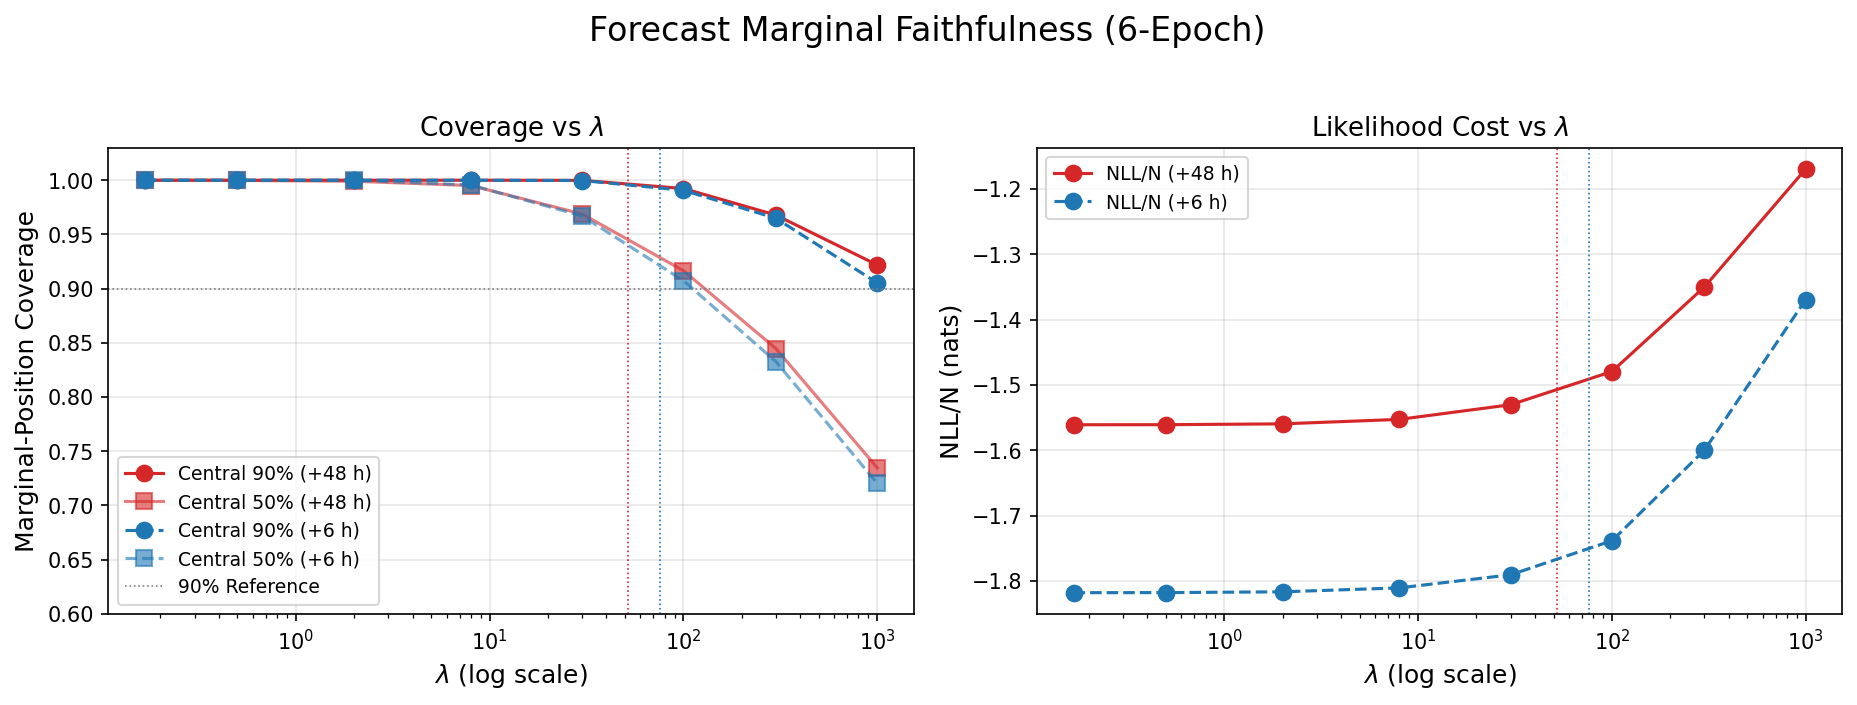

In [4]:
show(FIG / "forecast_faithfulness_14ep.png", width=1150)
show(FIG / "forecast_faithfulness_6ep.png", width=1150)

=== 14ep +48h ===


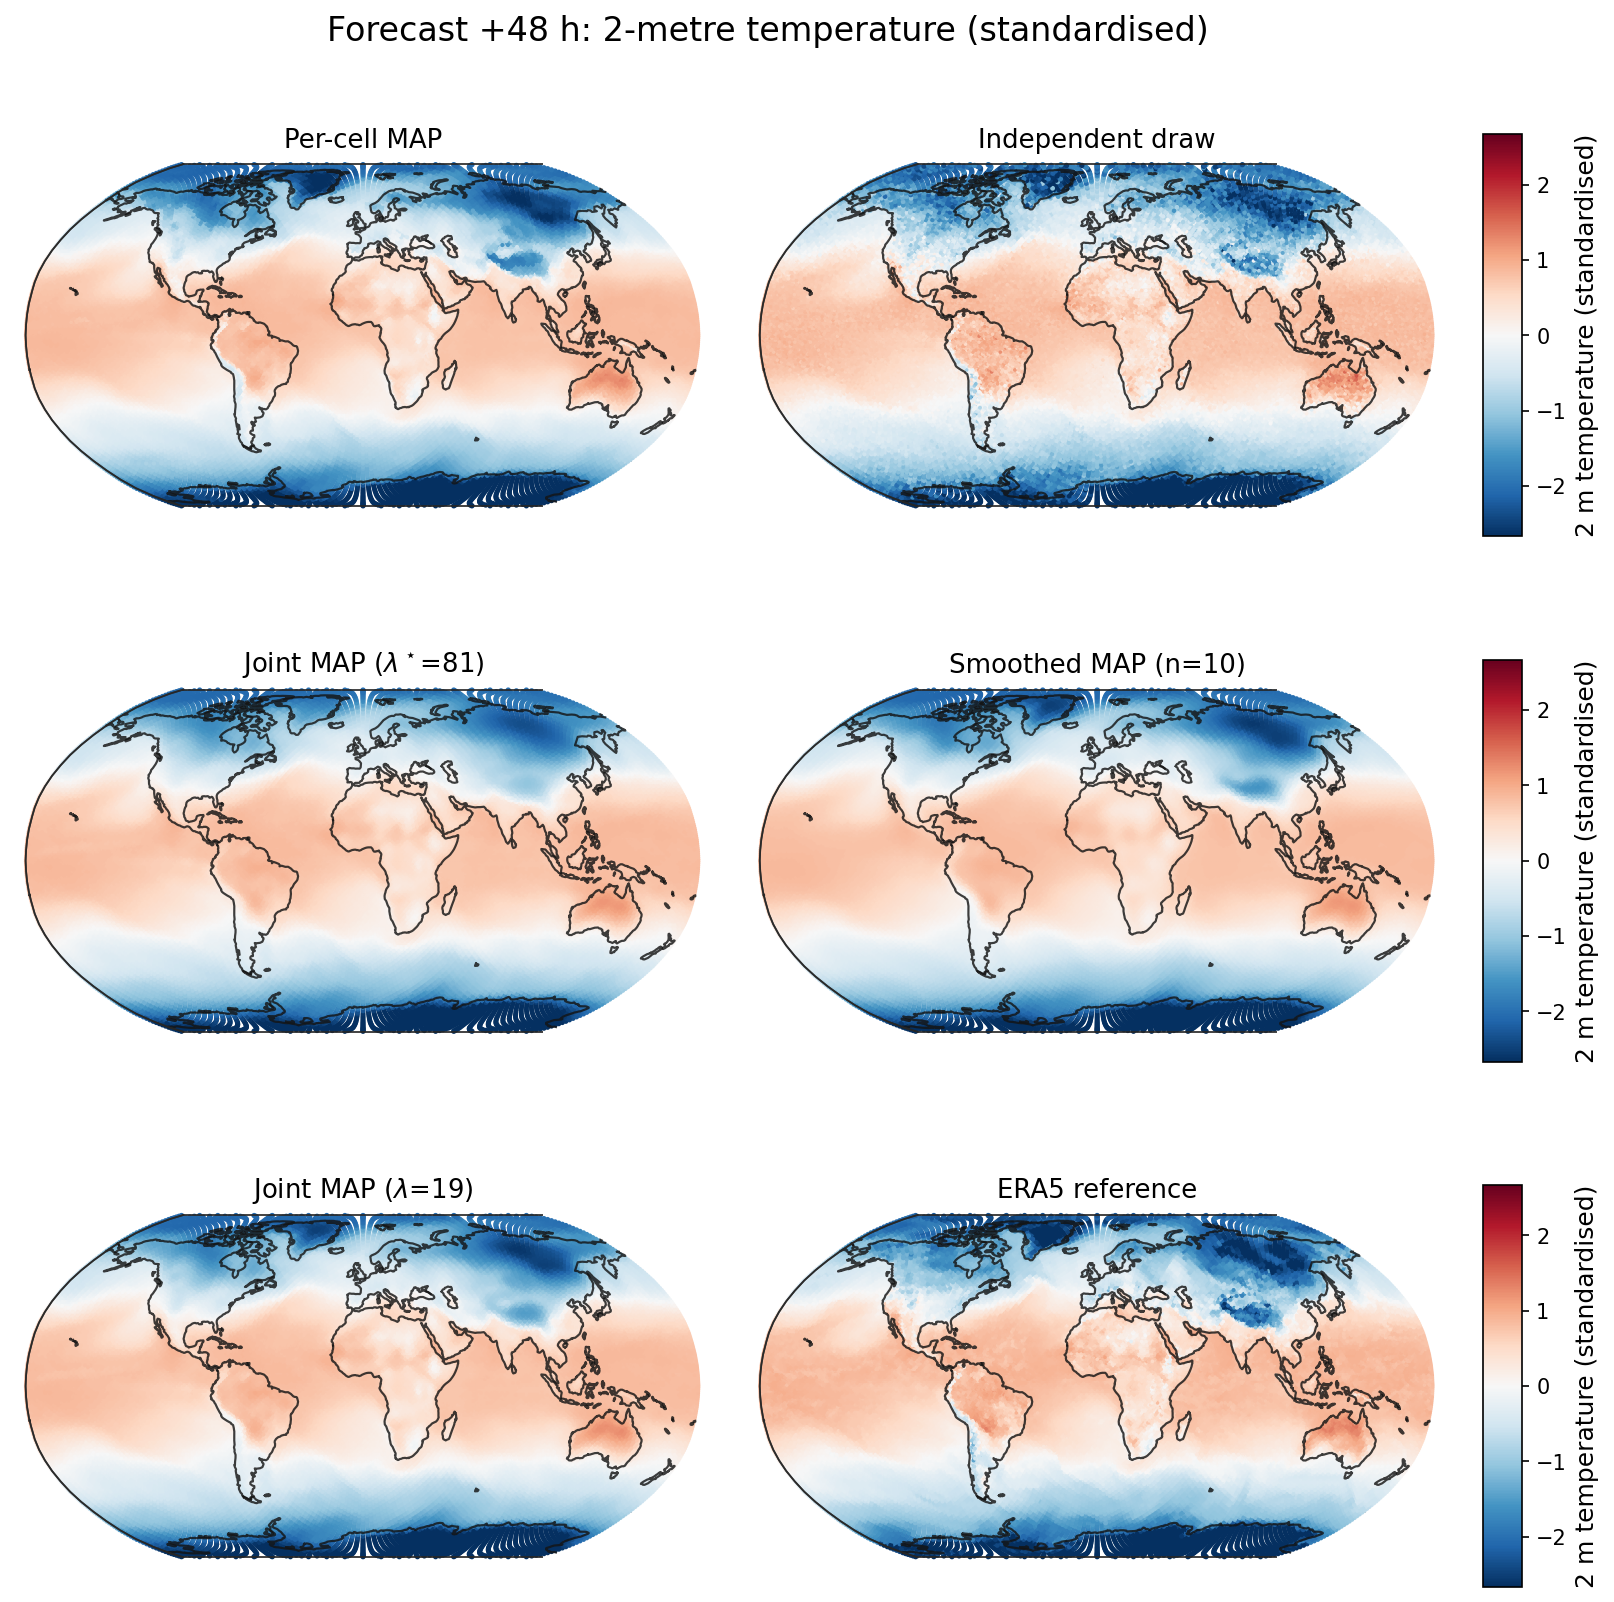

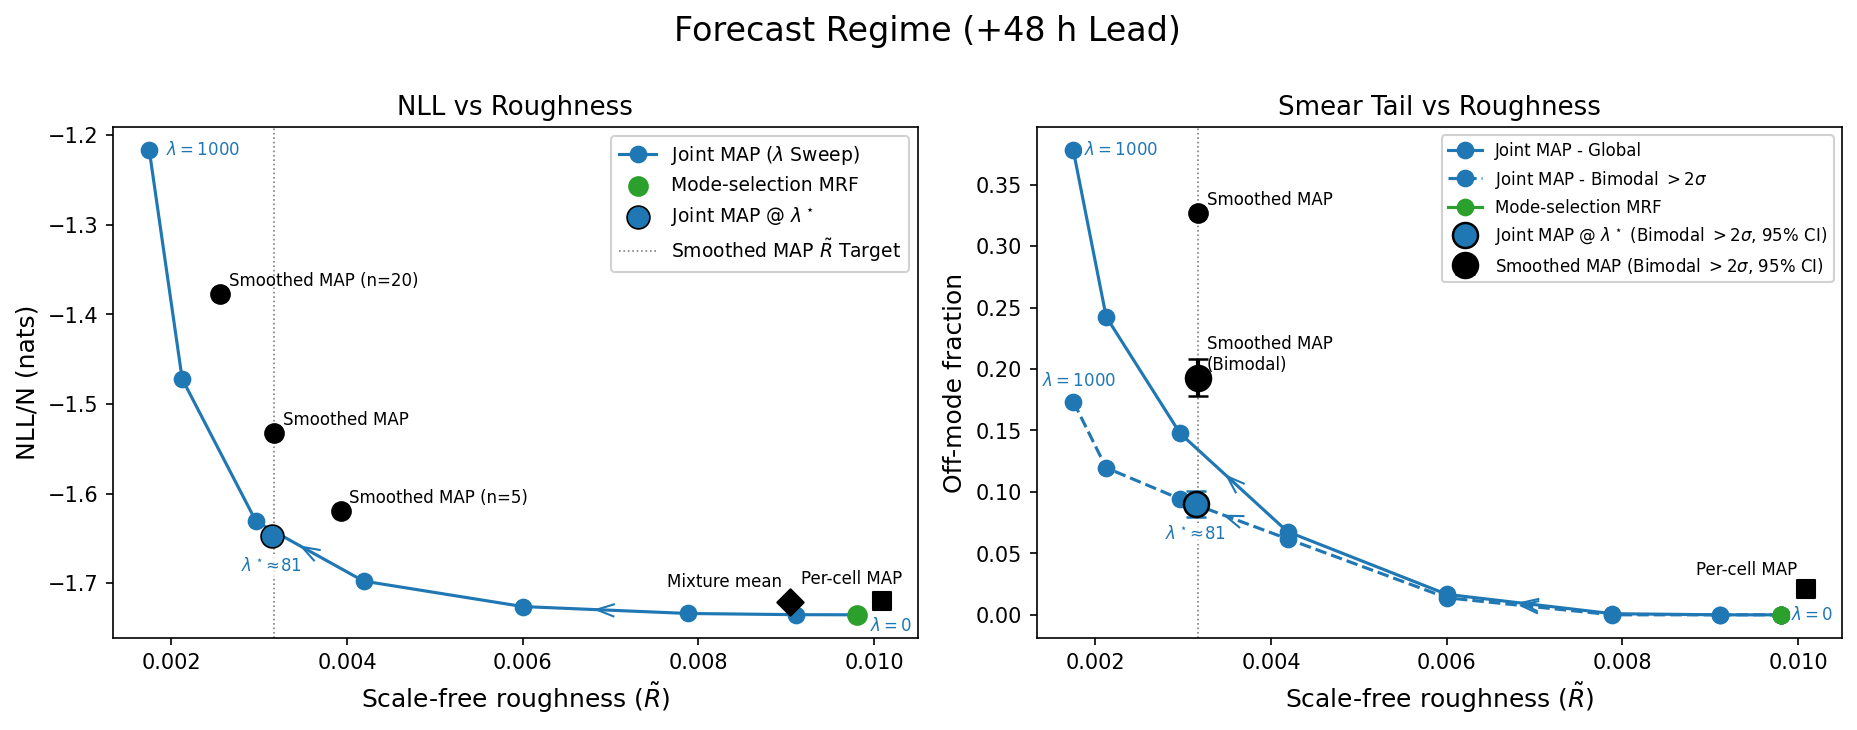

=== 6ep +48h ===


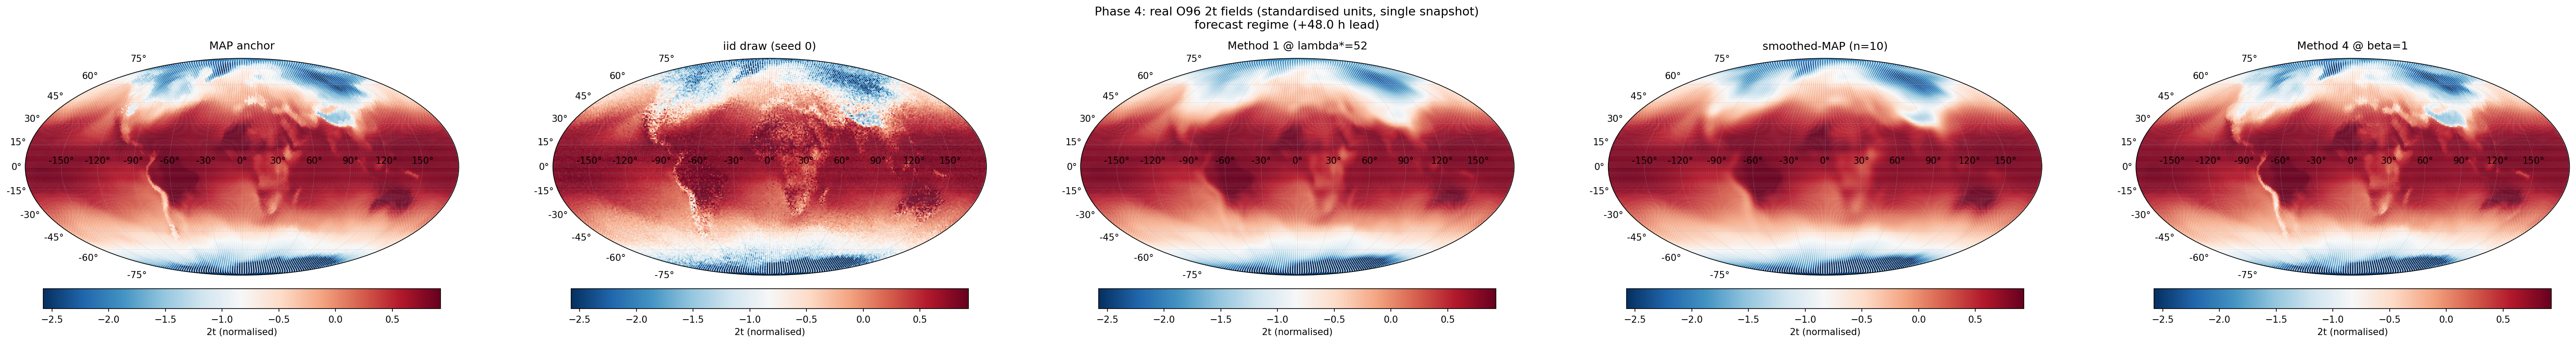

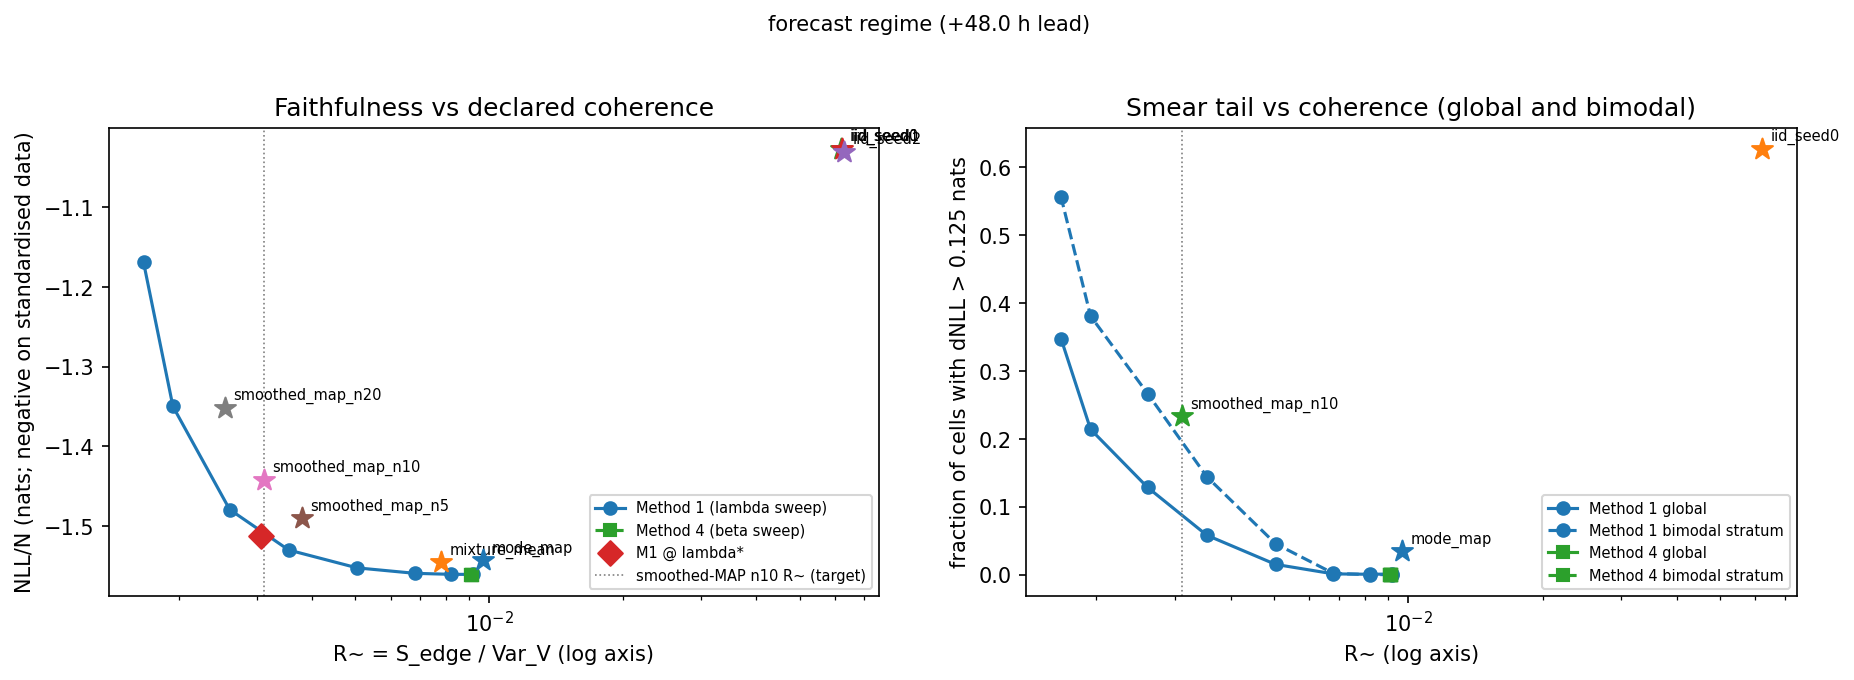

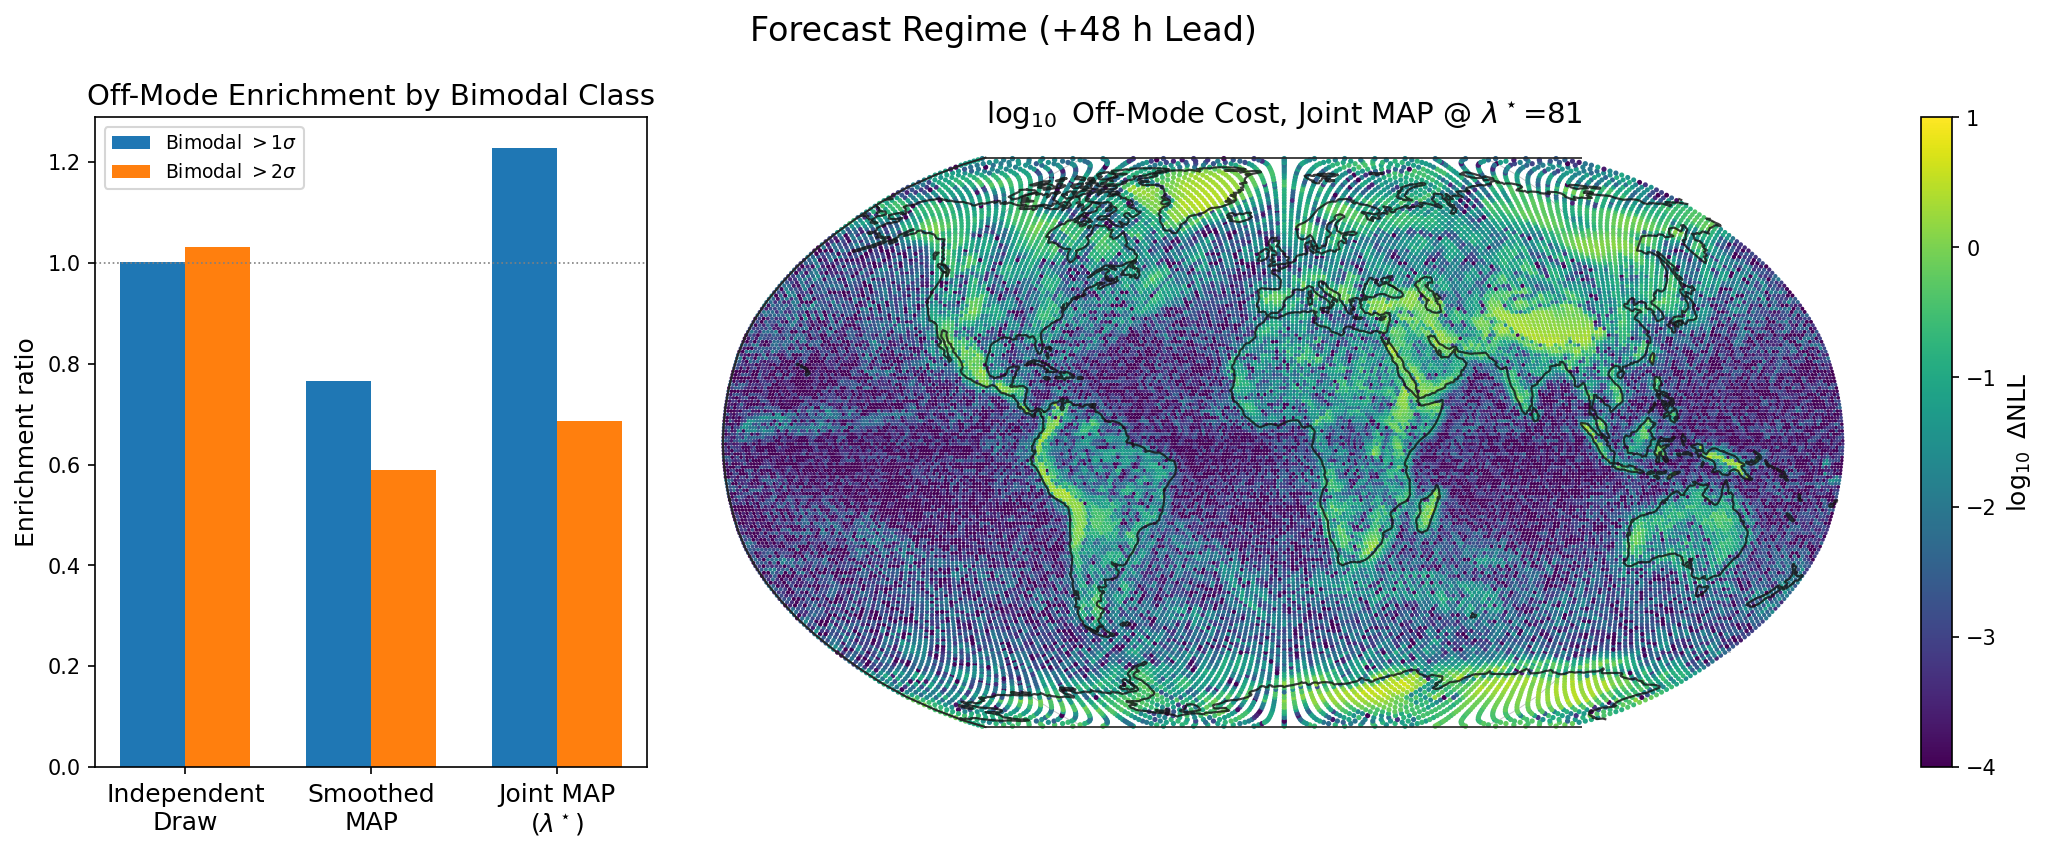

In [5]:
# Headline lead +48h (14ep), then +48h (6ep) for the training contrast.
for label, step in (("14ep", 8), ("6ep", 8)):
    fd = FIG / f"{PREFIX[label].replace('phase_4_fc48_', 'forecast_')}_step{step}"
    print(f"=== {label} +{6*step}h ===")
    show(fd / "maps.png")
    show(fd / "pareto_smear.png")
fd = FIG / f"{PREFIX['14ep'].replace('phase_4_fc48_', 'forecast_')}_step8"
show(fd / "bimodal_enrichment.png")

### Behaviour under soft mixture weights (reserved slot)

In [6]:
def scores_rows(d):
    p = d / "scores.csv"
    return list(csv.DictReader(open(p))) if p.exists() else []

hdr = (f"{'run':>5} {'lead':>5} {'Joint MAP NLL/N':>15} {'Smoothed MAP NLL/N':>18} "
       f"{'Joint MAP tail':>14} {'Smoothed MAP tail':>17} {'MRF pinned':>11}")
print(hdr); print("-"*len(hdr))
for label in ("6ep", "14ep"):
    for step, d in sorted(lead_dirs(label).items()):
        bn = {r["name"]: r for r in scores_rows(d)}
        m1, sm = bn.get("m1_star"), bn.get("smoothed_map_n10")
        if not (m1 and sm):
            continue
        pinned = "n/a"
        mp = d / "method4_sweep.npz"
        if mp.exists():
            f = dict(np.load(mp))
            pinned = str(bool(np.ptp(f["fields"], axis=0).max() <= 1e-9))
        print(f"{label:>5} +{6*step:>2}h {float(m1['nll_over_n']):>15.4f} {float(sm['nll_over_n']):>18.4f} "
              f"{float(m1['dnll_frac_gt_0p125']):>14.3f} {float(sm['dnll_frac_gt_0p125']):>17.3f} {pinned:>11}")

  run  lead Joint MAP NLL/N Smoothed MAP NLL/N Joint MAP tail Smoothed MAP tail  MRF pinned
-------------------------------------------------------------------------------------------
  6ep + 6h         -1.7551            -1.6049          0.108             0.352       False


  6ep +12h         -1.6560            -1.5480          0.096             0.298       False
  6ep +18h         -1.6020            -1.5086          0.091             0.273       False


  6ep +24h         -1.5871            -1.4992          0.092             0.267       False
  6ep +30h         -1.5513            -1.4694          0.086             0.252       False
  6ep +36h         -1.5189            -1.4464          0.081             0.233       False
  6ep +42h         -1.5078            -1.4367          0.081             0.233       False


  6ep +48h         -1.5129            -1.4421          0.086             0.234       False
 14ep + 6h         -1.8670            -1.6420          0.162             0.451       False
 14ep +12h         -1.7949            -1.6349          0.142             0.398       False


 14ep +18h         -1.7729            -1.6152          0.153             0.398       False


 14ep +24h         -1.7568            -1.6107          0.148             0.384       False
 14ep +30h         -1.7166            -1.5725          0.144             0.357       False
 14ep +36h         -1.6751            -1.5583          0.131             0.328       False


 14ep +42h         -1.6612            -1.5444          0.133             0.328       False
 14ep +48h         -1.6470            -1.5329          0.132             0.327       False


## §5.5 — Consistency with the emitted distributions

In [7]:
hdr = f"{'run':>5} {'lead':>5} {'cov90':>8} {'cov50':>8}"
print(hdr); print("-"*len(hdr))
for r in faith:
    if r["kind"] != "single":  # reference initialisation, as tabulated in the report
        continue
    print(f"{r['run']:>5} +{float(r['lead_hours']):>2.0f}h {float(r['m1_star_cov90']):>8.3f} "
          f"{float(r['m1_star_cov50']):>8.3f}")
print("\nCentral marginal-position coverage: where each selected value sits within its own")
print("emitted mixture. This is not an ensemble-calibration claim.")


  run  lead    cov90    cov50
-----------------------------
  6ep + 6h    0.994    0.922
  6ep +12h    0.996    0.934
  6ep +18h    0.997    0.943
  6ep +24h    0.997    0.945
  6ep +30h    0.997    0.949
  6ep +36h    0.998    0.953
  6ep +42h    0.998    0.952
  6ep +48h    0.998    0.949
 14ep + 6h    0.983    0.883
 14ep +12h    0.987    0.902
 14ep +18h    0.987    0.896
 14ep +24h    0.986    0.901
 14ep +30h    0.986    0.904
 14ep +36h    0.988    0.914
 14ep +42h    0.990    0.913
 14ep +48h    0.990    0.915

Central marginal-position coverage: where each selected value sits within its own
emitted mixture. This is not an ensemble-calibration claim.


## Transfer of calibration across regimes

In [8]:
ae_p = RUNS / "phase_4_real" / "lambda_star.json"
ae_lam = json.loads(ae_p.read_text())["lambda_star"] if ae_p.exists() else 93.74
print(f"AE reconstruction lambda* = {ae_lam:.2f} (step-0, near-one-hot)")
for label in ("6ep", "14ep"):
    lams = []
    for step, d in sorted(lead_dirs(label).items()):
        p = d / "lambda_star.json"
        if p.exists():
            lams.append((6 * step, json.loads(p.read_text())["lambda_star"]))
    if lams:
        print(f"{label:>5}: " + "  ".join(f"+{h}h={l:.1f}" for h, l in lams))

AE reconstruction lambda* = 93.74 (step-0, near-one-hot)
  6ep: +6h=75.8  +12h=61.3  +18h=56.3  +24h=56.2  +30h=51.4  +36h=47.0  +42h=48.1  +48h=52.0
 14ep: +6h=116.3  +12h=91.5  +18h=97.6  +24h=97.0  +30h=88.1  +36h=78.5  +42h=80.6  +48h=81.3
